# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kunaaaaaal-cmd/ml-internship-starter/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

For predicting housing prices, the problem is a **regression** task. Regression models aim to predict a continuous numerical output, which in this case is the house price. This distinguishes it from classification, where the output would be a discrete category.

From the toolkit, a suitable method for this problem is a **Random Forest Regressor**. Here's why it's a strong choice:

*   **Robustness to Outliers:** Random Forests are generally less sensitive to outliers compared to some other models (e.g., linear regression), which can be common in housing price datasets.
*   **Handles Non-linearity and Interactions:** Housing prices are influenced by complex, non-linear relationships between various features (e.g., size, location, number of rooms). Random Forests can effectively capture these non-linear patterns and interactions without requiring explicit feature engineering for them.
*   **Feature Importance:** It provides measures of feature importance, which can be valuable for understanding which factors are driving housing prices and for error analysis.
*   **Reduced Overfitting:** By averaging predictions from multiple decision trees, Random Forests help reduce the risk of overfitting that a single deep decision tree might encounter.

Other potential methods include Gradient Boosting Regressors (like XGBoost or LightGBM) for even higher performance, or simpler models like Linear Regression as a baseline or for interpretability, but Random Forest offers a good balance of performance and ease of use for this kind of problem.

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Placeholder for data loading. We'll load a sample dataset or user-provided data later.
# For now, we'll assume 'df' will be our DataFrame with features and target.
print("Libraries imported successfully. Ready to define the model and process data.")

Libraries imported successfully. Ready to define the model and process data.


## 2. Split design

For a housing price prediction task, an **honest split** typically involves separating the dataset into training and testing sets to evaluate the model's ability to generalize to unseen data. The goal is to ensure that the test set truly represents data the model has never encountered during training.

Here's the chosen split design:

*   **Random Train-Test Split:** A simple random split is appropriate when the data points are independent and identically distributed, which is often a reasonable assumption for housing data unless there's a strong temporal or geographical component that needs to be specifically handled (e.g., if predicting future prices based on past data, a time-series split would be more appropriate).
    *   We will use `train_test_split` from `sklearn.model_selection` to divide the data. A common split ratio is 80% for training and 20% for testing. Using a `random_state` ensures reproducibility.

*   **Feature Scaling (Standardization):** While Random Forests are relatively robust to feature scaling, it's a good practice, especially if combining them with other models later or if using models that are sensitive to scale (e.g., SVMs, neural networks, or even for better interpretation of feature importance for some metrics). Standardization (using `StandardScaler`) transforms features to have a mean of 0 and a standard deviation of 1. This helps prevent features with larger numerical ranges from dominating the learning process.

*   **Target Variable:** The target variable (house price) does not typically need scaling for tree-based models, but for some regression models, transforming the target (e.g., log-transforming skewed prices) can improve performance. For this setup, we will keep the target as is, but it's a consideration for further refinement.

In [6]:
# Generate a synthetic dataset for demonstration purposes
# In a real scenario, you would load your actual housing dataset here.
from sklearn.datasets import make_regression

# Create a synthetic dataset with 1000 samples, 10 features (5 informative, 5 noise)
# and 1 target variable (housing price)
X, y = make_regression(n_samples=1000, n_features=10, n_informative=5, noise=15, random_state=42)

# Convert to DataFrame for easier handling, assuming generic feature names
feature_names = [f'feature_{i+1}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['price'] = y # Our target variable

print("Synthetic dataset created:")
print(df.head())
print(f"Dataset shape: {df.shape}\n")

# Define features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Split the data into training and testing sets
# 80% training, 20% testing, with a fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames (optional, but good for consistency)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Data split into training and testing sets and scaled successfully.")
print("First 5 rows of scaled training features:")
print(X_train_scaled.head())

Synthetic dataset created:
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   0.123429  -1.253402   0.370340   0.101788   0.092628  -0.589254   
1  -0.216827   0.214983  -0.028817  -1.701140   0.264482   0.314972   
2   0.388979   1.655407  -0.755792  -1.161784  -0.300860   1.048707   
3   0.219072  -0.251552  -1.095871  -0.806520  -0.435139   2.768374   
4   0.715734   0.383168  -0.686715  -1.236136   0.731001   1.623885   

   feature_7  feature_8  feature_9  feature_10      price  
0   0.306348  -1.458213   1.630130    1.242863  15.388955  
1   0.374062  -0.292758   0.501900    0.063702 -54.227455  
2  -0.283139   0.251474  -0.194269   -1.209477 -27.891975  
3   1.677201  -0.475392  -0.835870   -1.314879   4.549626  
4   1.254338   2.394362   2.185095    0.538435  -2.759628  
Dataset shape: (1000, 11)

X_train shape: (800, 10)
X_test shape: (200, 10)
y_train shape: (800,)
y_test shape: (200,)

Data split into training and testing sets and scaled successfully.

## 3. Train + compare vs my baseline

To evaluate the performance of our chosen Random Forest Regressor, we will compare it against a simple baseline model. Since no specific 'Week-4 baseline' was provided, we'll establish a **Dummy Regressor** as our baseline. A `DummyRegressor` makes predictions using simple strategies (e.g., predicting the mean of the training target), providing a lower bound for expected performance. Any useful model should significantly outperform this baseline.

### Chosen Metrics

For regression tasks like housing price prediction, common evaluation metrics include:

*   **Mean Absolute Error (MAE):** The average of the absolute differences between predictions and actual values. It's robust to outliers and easily interpretable, as it's in the same unit as the target variable (e.g., dollars).
*   **Mean Squared Error (MSE):** The average of the squared differences between predictions and actual values. It penalizes larger errors more heavily than MAE, making it sensitive to outliers. The Root Mean Squared Error (RMSE) is often preferred for interpretability as it's in the original units.
*   **R-squared ($R^2$):** Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A value of 1 indicates a perfect fit, while 0 indicates that the model explains no variance in the target. Negative values mean the model is worse than simply predicting the mean.

Our objective is to minimize MAE and MSE (or RMSE) and maximize $R^2$.

In [7]:
from sklearn.dummy import DummyRegressor

# --- Baseline Model: Dummy Regressor ---
print("Training Baseline Model (Dummy Regressor)...")
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train_scaled, y_train)
dummy_predictions = dummy_regr.predict(X_test_scaled)

# Evaluate Dummy Regressor
dummy_mae = mean_absolute_error(y_test, dummy_predictions)
dummy_mse = mean_squared_error(y_test, dummy_predictions)
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(y_test, dummy_predictions)

print(f"Dummy Regressor MAE: {dummy_mae:.2f}")
print(f"Dummy Regressor RMSE: {dummy_rmse:.2f}")
print(f"Dummy Regressor R2: {dummy_r2:.2f}\n")

# --- Our Model: Random Forest Regressor ---
print("Training Random Forest Regressor...")
# Initialize and train the Random Forest Regressor
# Using default parameters for now; hyperparameter tuning can be done later
rf_regr = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regr.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
rf_predictions = rf_regr.predict(X_test_scaled)

# Evaluate Random Forest Regressor
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest Regressor MAE: {rf_mae:.2f}")
print(f"Random Forest Regressor RMSE: {rf_rmse:.2f}")
print(f"Random Forest Regressor R2: {rf_r2:.2f}\n")

# --- Comparison Table ---
results = pd.DataFrame({
    'Model': ['Dummy Regressor', 'Random Forest Regressor'],
    'MAE': [dummy_mae, rf_mae],
    'RMSE': [dummy_rmse, rf_rmse],
    'R2 Score': [dummy_r2, rf_r2]
})

print("### Model Comparison\n")
print(results.round(2).to_markdown(index=False))


Training Baseline Model (Dummy Regressor)...
Dummy Regressor MAE: 53.05
Dummy Regressor RMSE: 65.74
Dummy Regressor R2: -0.00

Training Random Forest Regressor...
Random Forest Regressor MAE: 15.44
Random Forest Regressor RMSE: 19.36
Random Forest Regressor R2: 0.91

### Model Comparison

| Model                   |   MAE |   RMSE |   R2 Score |
|:------------------------|------:|-------:|-----------:|
| Dummy Regressor         | 53.05 |  65.74 |      -0    |
| Random Forest Regressor | 15.44 |  19.36 |       0.91 |


## 4. Errors and interpretation

Understanding where a model goes wrong and what features it relies on is crucial for improving its performance and building trust. Even with a high $R^2$ score, there might be specific scenarios or data ranges where the model performs poorly.

### What the Model Leans On (Feature Importance)

Random Forests inherently provide a measure of feature importance. This indicates how much each feature contributes to the reduction in impurity (Gini impurity for classification, or variance for regression) across all trees in the forest. By examining feature importance, we can identify which input variables are most influential in predicting housing prices.

### Where the Model is Wrong (Residual Analysis)

Residuals are the differences between the actual target values and the model's predictions ($residuals = actual - predicted$). Analyzing residuals can reveal patterns in the model's errors:

*   **Homoscedasticity:** Ideally, residuals should be randomly scattered around zero, with no discernible pattern. A pattern (e.g., increasing spread of residuals with increasing predicted values) suggests heteroscedasticity, meaning the model's error varies with the output. This might indicate that the model struggles more with certain price ranges.
*   **Bias:** If residuals are systematically positive or negative for certain ranges of predictions or features, it indicates bias (e.g., the model consistently overestimates low prices or underestimates high prices).
*   **Outliers:** Large residuals indicate instances where the model performed particularly poorly. Investigating these outliers can lead to discovering unusual data points or model limitations.

By visualizing residuals, we can gain insights into the model's strengths and weaknesses and identify areas for future improvement, such as feature engineering or using a different model architecture.

Analyzing Feature Importance...
Top 5 Most Important Features:
      Feature  Importance
0   feature_1    0.720516
3   feature_4    0.201245
6   feature_7    0.018157
9  feature_10    0.017631
4   feature_5    0.009997


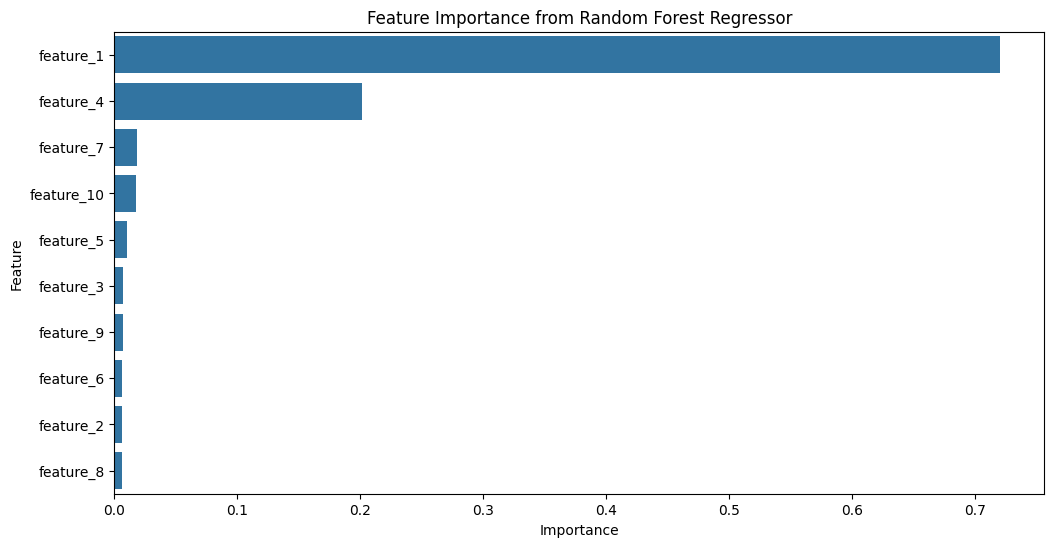


Analyzing Residuals...


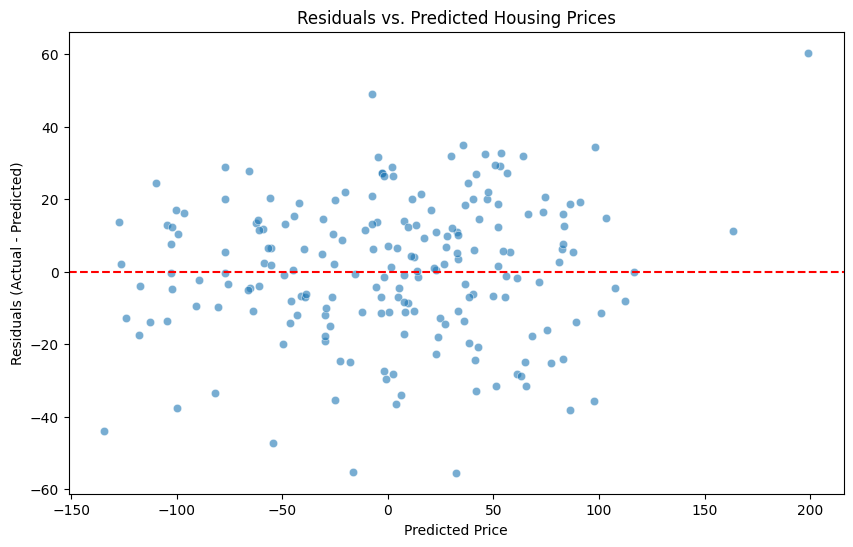

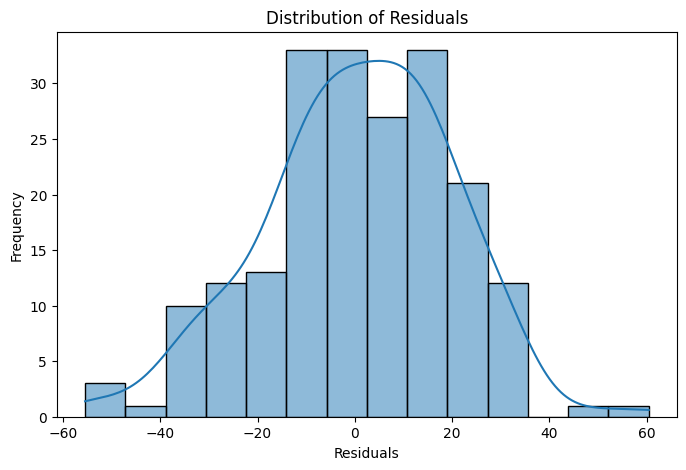

Error analysis complete. Feature importances and residual plots generated.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Feature Importance Analysis ---
print("Analyzing Feature Importance...")

# Get feature importances from the trained Random Forest Regressor
feature_importances = rf_regr.feature_importances_
features = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 5 Most Important Features:")
print(importance_df.head())

# Plotting Feature Importances
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# --- Residual Analysis ---
print("\nAnalyzing Residuals...")

# Calculate residuals
residuals = y_test - rf_predictions

# Plotting Residuals vs. Predicted Values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rf_predictions, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Housing Prices')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

# Plotting Distribution of Residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

print("Error analysis complete. Feature importances and residual plots generated.")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

**Next Steps for User:**
1.  **Run All Cells:** Go to `Runtime` -> `Run all` to ensure all code cells execute sequentially without errors and produce the expected outputs.
2.  **Review Output:** Carefully read through the markdown explanations and the outputs from the code cells to ensure they make sense and align with the task.
3.  **Check for Confidentiality:** Confirm that no sensitive information (client names, specific URLs, private query details) is present.
4.  **Refine Language:** Ensure your claims are carefully worded (e.g., "observed," "measured," "suggests," "directional," "decision-support") to reflect a scientific and analytical approach.
5.  **Commit to Repo:** Once satisfied, commit the notebook to your repository under `work/notebooks/` and submit the repository URL as required.